Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<class 'pandas.DataFrame'>
RangeIndex: 100002 entries, 0 to 100001
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Nama User  100002 non-null  str    
 1   Ulasan     100001 non-null  str    
 2   Rating     100000 non-null  float64
 3   Tanggal    100000 non-null  str    
 4   Likes      100000 non-null  float64
 5   Versi App  72298 non-null   float64
dtypes: float64(3), str(3)
memory usage: 4.6 MB
None
Nama User        0
Ulasan           1
Rating           2
Tanggal          2
Likes            2
Versi App    27704
dtype: int64
Nama User    0
Ulasan       1
Rating       2
Tanggal      2
Likes        2
Versi App    0
dtype: int64
Contoh Keluhan User (Bintang 1)
2     ga bisa denger lagu JKT48 lagi gara² selalu di...
4     kenapa sih, aku cuman bisa main 5 lagu doang? ...
13                                    harga paket mahal
16                             banyak iklan mending MOD
39    ini kenapa kita tidak bisa p

C:\Users\USER\AppData\Local\Temp\ipykernel_31652\596662579.py:33: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_spotify['Tanggal']= pd.to_datetime(df_spotify['Tanggal'])
C:\Users\USER\AppData\Local\Temp\ipykernel_31652\596662579.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_spotify, x='Rating', palette='viridis')


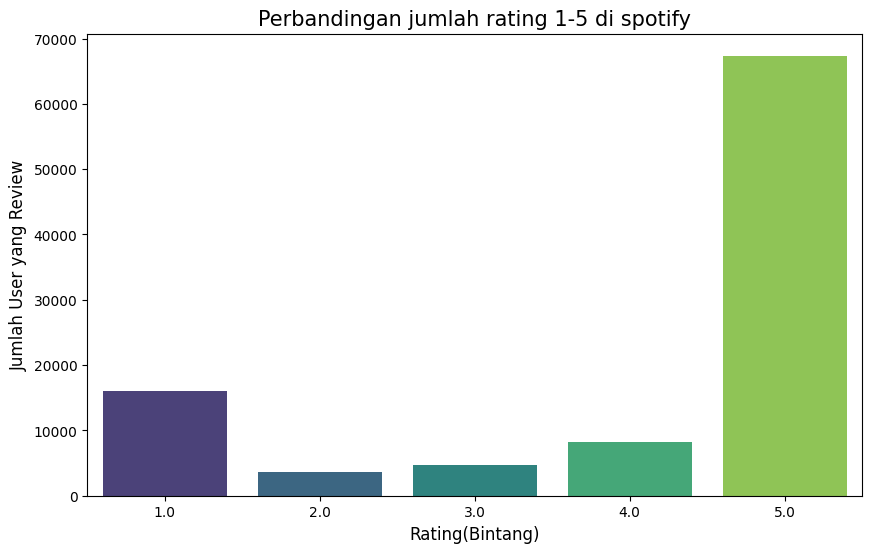

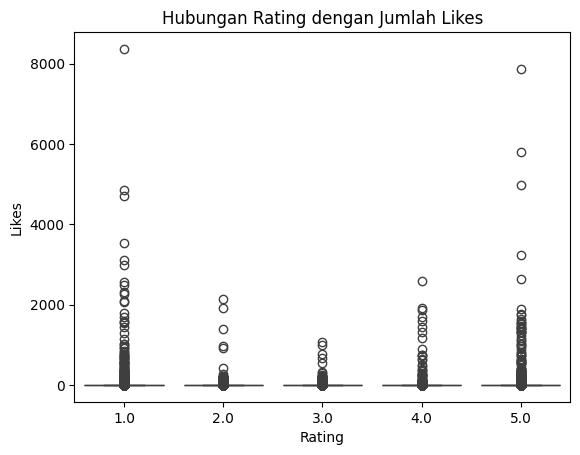

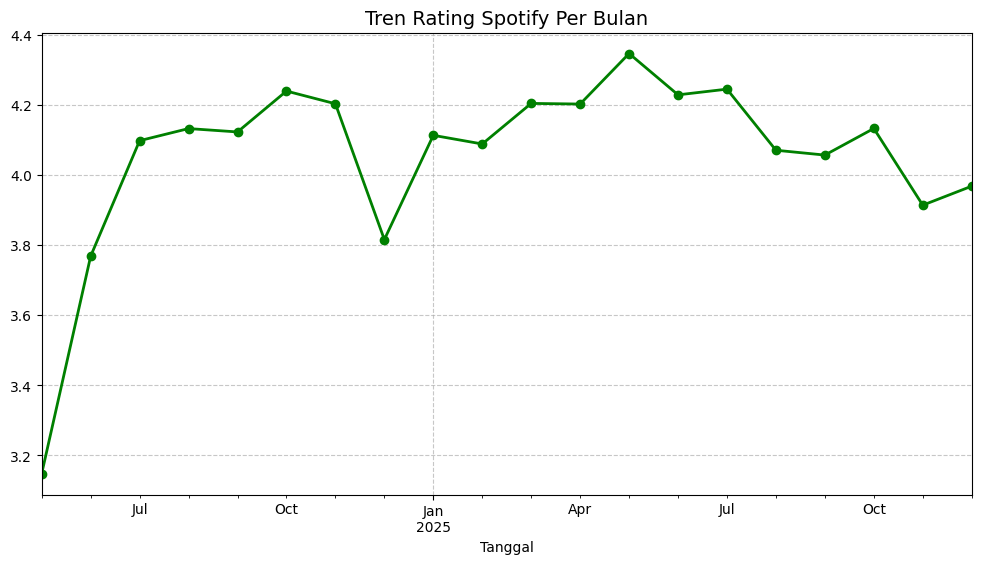

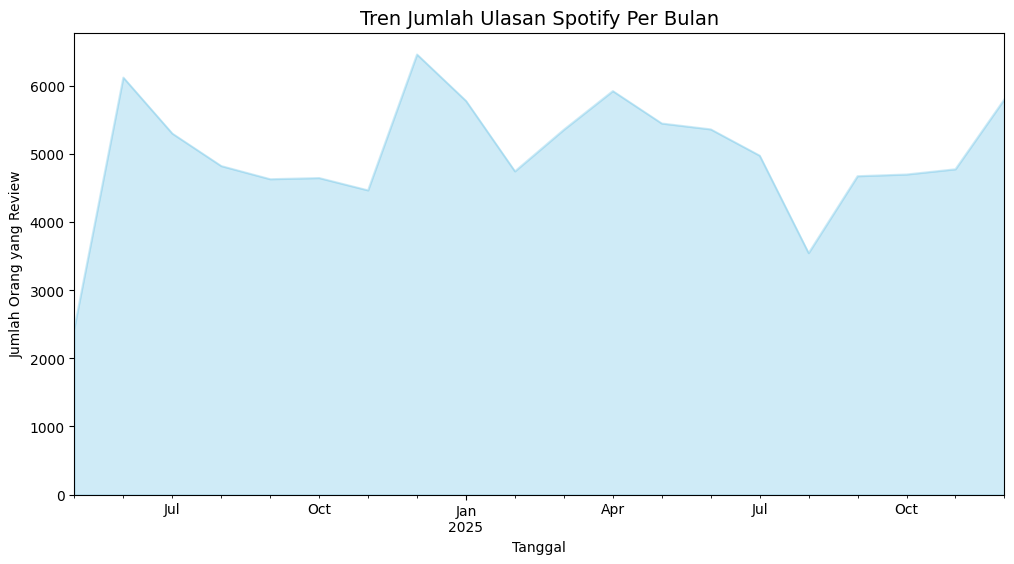

C:\Users\USER\AppData\Local\Temp\ipykernel_31652\596662579.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_version, x='Versi App', y='Rating', palette='coolwarm')


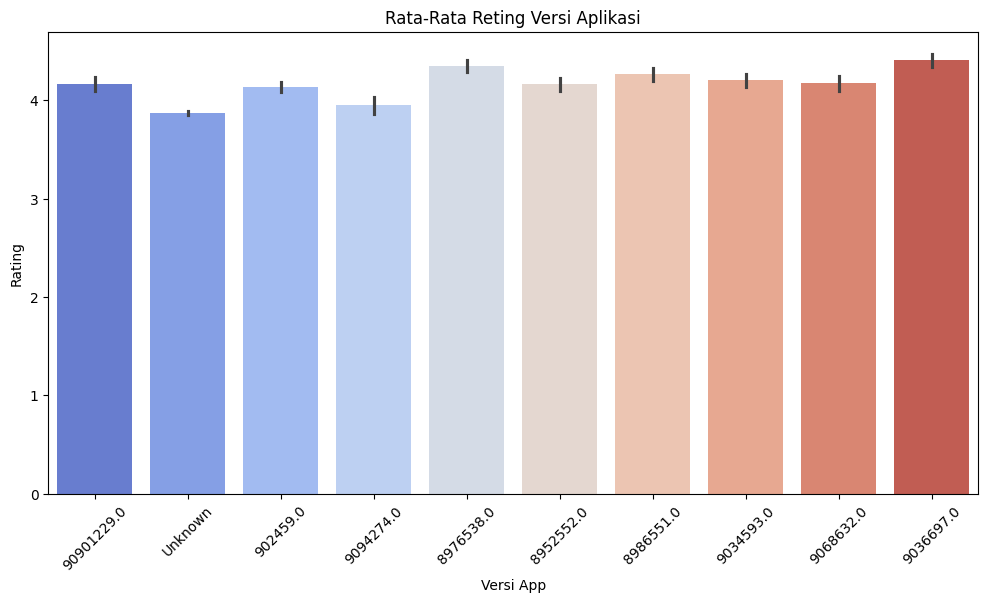

Analisa Kata Kunci Ulasan Negatif:
- Masalah Iklan: 3944 ulasan
- Masalah Bayar/Premium: 4948 ulasan
- Masalah Login/Akun: 838 ulasan
- Masalah Lirik: 717 ulasan
Top 10 Keluhan di Bulan Desember 2024:
[('premium', 622), ('lagu', 601), ('bisa', 408), ('iklan', 384), ('harus', 310), ('spotify', 273), ('aplikasi', 183), ('banyak', 179), ('lagi', 155), ('tidak', 154)]


In [ ]:
!pip install pandas numpy matplotlib
!pip install seaborn

import pandas as pd
df_spotify= pd.read_csv('Ulasan_spotify.csv', sep=';')
print(df_spotify.info())
df_spotify.isnull().sum()
df_clean= df_spotify.dropna()
print(df_spotify.isnull().sum())

df_spotify['Versi App'] = df_spotify['Versi App'].fillna('Unknown')
print(df_spotify.isnull().sum())

Ulasan_Buruk=df_spotify[df_spotify['Rating']== 1]
print("Contoh Keluhan User (Bintang 1)")
print(Ulasan_Buruk['Ulasan'].head(10))

df_spotify.drop(columns=['Nama User'], inplace=True)
df_spotify.head(10)

df_spotify.dtypes

Ulasan_Baik=df_spotify[df_spotify['Rating']== 5]
print("Contoh Ulasan Baik(Bintang5)")
print(Ulasan_Baik['Ulasan'].head(10))

jumlah_rating= df_spotify['Rating'].value_counts()
print(jumlah_rating)

df_spotify['Panjang_Ulasan']= df_spotify['Ulasan'].str.split().str.len()
print(df_spotify.groupby('Rating')['Panjang_Ulasan'].mean())

df_spotify['Tanggal']= pd.to_datetime(df_spotify['Tanggal'])
df_spotify.set_index('Tanggal').resample('ME')['Rating'].mean()
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df_spotify, x='Rating', palette='viridis')
plt.title('Perbandingan jumlah rating 1-5 di spotify', fontsize=15)
plt.xlabel('Rating(Bintang)', fontsize=12)
plt.ylabel('Jumlah User yang Review', fontsize=12)
plt.show()

sns.boxplot(data=df_spotify, x='Rating', y='Likes')
plt.title('Hubungan Rating dengan Jumlah Likes')
plt.show()

df_spotify['Tanggal']=pd.to_datetime(df_spotify['Tanggal'], dayfirst=True)
df_spotify['Bulan_Tahun']=df_spotify['Tanggal'].dt.to_period('M')

plt.figure(figsize=(12, 6))
tren_rating=df_spotify.set_index('Tanggal').resample('ME')['Rating'].mean()
tren_rating.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Tren Rating Spotify Per Bulan', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
volume_ulasan = df_spotify.set_index('Tanggal').resample('ME')['Ulasan'].count()
volume_ulasan.plot(kind='area', color='skyblue', alpha=0.4)
plt.title('Tren Jumlah Ulasan Spotify Per Bulan', fontsize=14)
plt.ylabel('Jumlah Orang yang Review')
plt.show()

top_version=df_spotify['Versi App'].value_counts().head(10).index
df_top_version=df_spotify[df_spotify['Versi App'].isin(top_version)]
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_version, x='Versi App', y='Rating', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Rata-Rata Reting Versi Aplikasi')
plt.show()

ulasan_negatif = df_spotify[df_spotify['Rating'] == 1]['Ulasan'].str.lower()
print("Analisa Kata Kunci Ulasan Negatif:")
print(f"- Masalah Iklan: {ulasan_negatif.str.contains('iklan|ads').sum()} ulasan")
print(f"- Masalah Bayar/Premium: {ulasan_negatif.str.contains('bayar|mahal|premium').sum()} ulasan")
print(f"- Masalah Login/Akun: {ulasan_negatif.str.contains('login|akun|masuk').sum()} ulasan")
print(f"- Masalah Lirik: {ulasan_negatif.str.contains('lirik|lyric').sum()} ulasan")







# 📊 Kesimpulan Akhir: Analisis Kepuasan Pengguna Spotify (2024)

## 1. Ringkasan Distribusi Rating
Berdasarkan analisis terhadap total data ulasan, ditemukan bahwa **Spotify memiliki loyalitas pengguna yang sangat tinggi** namun juga menghadapi kelompok **kritikus yang sangat vokal**.
* **Dominasi Bintang 5:** Sebanyak **67.371 ulasan** (mayoritas) memberikan rating sempurna, menunjukkan kepuasan pada fungsi utama aplikasi.
* **Fenomena Rating Ekstrem:** Terjadi polarisasi di mana jumlah **Rating 1.0 (16.088)** jauh lebih besar dibandingkan Rating 2, 3, dan 4. Pengguna cenderung memberikan rating sangat buruk ketika merasa kecewa, daripada memberikan rating menengah.

## 2. Temuan Kritis: Anomali Desember 2024
Ditemukan korelasi negatif yang signifikan pada periode akhir tahun:
* **Penurunan Rating:** Terjadi penurunan performa rata-rata dari **4.2 ke 3.8** dalam waktu satu bulan.
* **Lonjakan Keluhan:** Penurunan ini dibarengi dengan kenaikan volume ulasan ke titik tertinggi sepanjang tahun.
* **Analisis Akar Masalah (Root Cause):** Lonjakan ulasan ini merupakan bentuk protes masal. Berdasarkan *Text Mining*, indikasi utama mengarah pada masalah teknis pasca-update atau ketidakpuasan terhadap kebijakan fitur di periode tersebut.

## 3. Insight Interaksi (Likes vs Sentiment)
Melalui analisis *Boxplot*, ditemukan bahwa:
* **Sentimen Negatif Lebih Viral:** Ulasan dengan Rating 1.0 mendapatkan jumlah *Likes* paling masif (hingga 8.000+ per ulasan).
* **Validasi Keluhan:** Tingginya interaksi pada ulasan buruk menunjukkan bahwa satu keluhan teknis/kebijakan mewakili keresahan ribuan pengguna lainnya secara kolektif.

## 4. Rekomendasi Strategis
1. **Audit Tim QA:** Segera melakukan pengecekan ulang terhadap *deployment log* dan stabilisasi versi aplikasi yang dirilis pada bulan November-Desember 2024.
2. **Evaluasi Fitur:** Melakukan *Text Mining* lebih dalam pada kata kunci seperti "Iklan", "Lirik", atau "Error" untuk menentukan apakah masalah disebabkan oleh *bug* atau ketidakpuasan terhadap model bisnis.
3. **Manajemen Komunitas:** Memberikan respons cepat pada ulasan bintang 1 yang memiliki *Likes* tinggi untuk meredam sentimen negatif yang viral.
